<a href="https://colab.research.google.com/github/nunotfc-png/Caeser-Cipher/blob/master/C%C3%B3pia_de_EX06_ABC_Pareto_KPIs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EX06 — Análise ABC, Pareto e KPIs Operacionais
**UC: Análise de Dados de Negócio**

---

Classificação ABC de produtos, diagrama de Pareto, KPIs mensais (receita, margem, encomendas) e análise de impacto de descontos.

**Dataset:** Superstore Sales (Tableau/Kaggle) — dados simulados incluídos no notebook

**Outputs gerados:** `superstore_analise.csv` · `abc_produtos.csv` · `kpis_mensais.csv` · `pareto_abc.png`


In [ ]:
# @title ⚙️ Instalação de Dependências (executar uma vez por sessão)

# Todas as bibliotecas necessárias já estão pré-instaladas no Google Colab.
# pandas, numpy, scikit-learn, matplotlib, seaborn estão disponíveis por omissão.

In [ ]:
# Dataset: Superstore Sales (Tableau Sample / Kaggle)
# https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GREEN, ORANGE, RED = '#0891B2', '#0D9488', '#F59E0B', '#EF4444'

In [ ]:
# Os ficheiros ficam em /content/ (sessão temporária):
OUTPUT_DIR = '/content/'
print(f"Directório de output: {OUTPUT_DIR}")

Directório de output: /content/


## PARTE 1 — CARREGAMENTO

In [ ]:
# Ficheiro local carregado para o Colab
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

print("Shape:", df.shape)
print(df.head())
print(df.dtypes)

Shape: (9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0 

## PARTE 2 — ANÁLISE ABC DE PRODUTOS

In [ ]:
# Definir patamares
nivel_a = 80
nivel_b = 95

# Vendas por produto
vendas_produto = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .reset_index()
    .sort_values('Sales', ascending=False)
)

# Acumular e calcular % cumulativa
vendas_produto['Cumul_Sales']  = vendas_produto['Sales'].cumsum()
vendas_produto['Cumul_Pct']    = vendas_produto['Cumul_Sales'] / vendas_produto['Sales'].sum() * 100
vendas_produto['Rank_Pct']     = np.arange(1, len(vendas_produto) + 1) / len(vendas_produto) * 100

# Classificar ABC
def classificar_abc(cumul_pct):
    if cumul_pct <= nivel_a:
        return 'A'
    elif cumul_pct <= nivel_b:
        return 'B'
    else:
        return 'C'

vendas_produto['Classe_ABC'] = vendas_produto['Cumul_Pct'].apply(classificar_abc)
print("\nClassificação ABC:")
print(vendas_produto[['Sub-Category', 'Sales', 'Cumul_Pct', 'Classe_ABC']])


Classificação ABC:
   Sub-Category        Sales   Cumul_Pct Classe_ABC
13       Phones  330007.0540   14.365616          A
5        Chairs  328449.1030   28.663412          A
14      Storage  223843.6080   38.407602          A
16       Tables  206965.5320   47.417068          A
3       Binders  203412.7330   56.271876          A
11     Machines  189238.6310   64.509669          A
0   Accessories  167380.3180   71.795941          A
6       Copiers  149528.0300   78.305082          A
4     Bookcases  114879.9963   83.305950          B
1    Appliances  107532.1610   87.986958          B
9   Furnishings   91705.1640   91.978998          B
12        Paper   78479.2060   95.395295          C
15     Supplies   46673.5380   97.427052          C
2           Art   27118.7920   98.607567          C
7     Envelopes   16476.4020   99.324805          C
10       Labels   12486.3120   99.868349          C
8     Fasteners    3024.2800  100.000000          C


## PARTE 3 — DIAGRAMA ABC

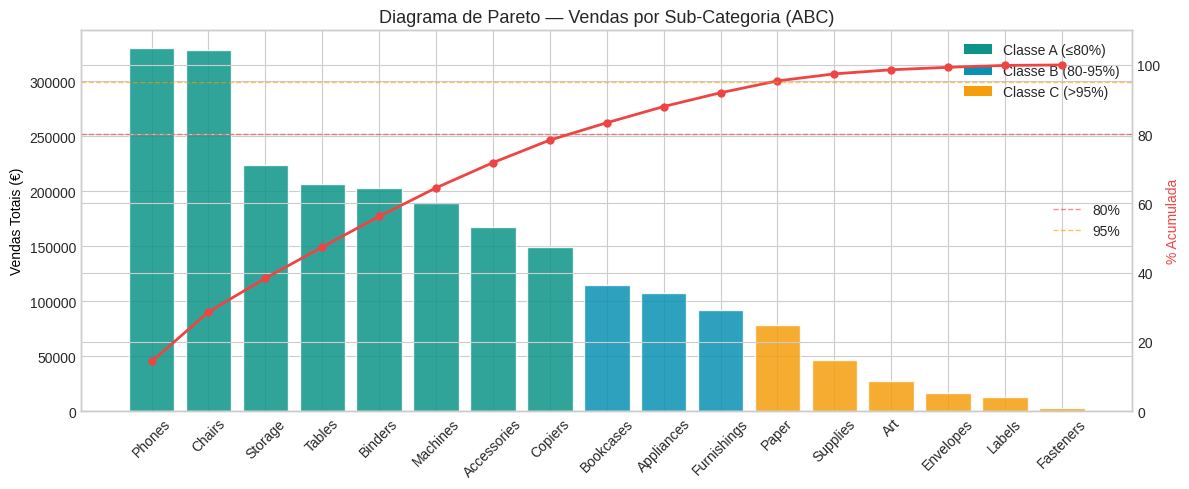

In [ ]:
# Apresenta os produtos pelos segmentos ABC de vendas

fig, ax1 = plt.subplots(figsize=(12, 5))

cores_abc = {'A': GREEN, 'B': BLUE, 'C': ORANGE}
bar_colors = [cores_abc[c] for c in vendas_produto['Classe_ABC']]

bars = ax1.bar(
    vendas_produto['Sub-Category'],
    vendas_produto['Sales'],
    color=bar_colors,
    alpha=0.85,
    edgecolor='white'
)
ax1.set_ylabel('Vendas Totais (€)', color='black')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    vendas_produto['Sub-Category'],
    vendas_produto['Cumul_Pct'],
    color=RED, marker='o', linewidth=2, markersize=5
)
ax2.axhline(80, color=RED, linestyle='--', linewidth=1, alpha=0.6, label='80%')
ax2.axhline(95, color=ORANGE, linestyle='--', linewidth=1, alpha=0.6, label='95%')
ax2.set_ylabel('% Acumulada', color=RED)
ax2.set_ylim(0, 110)
ax2.legend(loc='center right')

# Legenda ABC
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=GREEN, label='Classe A (≤80%)'),
                   Patch(facecolor=BLUE,  label='Classe B (80-95%)'),
                   Patch(facecolor=ORANGE,label='Classe C (>95%)')]
ax1.legend(handles=legend_elements, loc='upper right')
ax1.set_title('Diagrama de Pareto — Vendas por Sub-Categoria (ABC)', fontsize=13)

plt.tight_layout()
plt.savefig('/content/pareto_abc.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 4 — KPIs OPERACIONAIS


KPIs Mensais (últimos 6 meses):
YearMonth_str  Receita_Total  Lucro_Total  Margem_Media_pct  Num_Encomendas
      2017-07     45264.4160    6952.6212         15.414350             111
      2017-08     63120.8880    9040.9557         15.834334             111
      2017-09     87866.6520   10991.5556         14.893707             226
      2017-10     77776.9232    9275.2755          8.770513             147
      2017-11    118447.8250    9690.1037         11.212450             261
      2017-12     83829.3188    8483.3468         13.342715             224


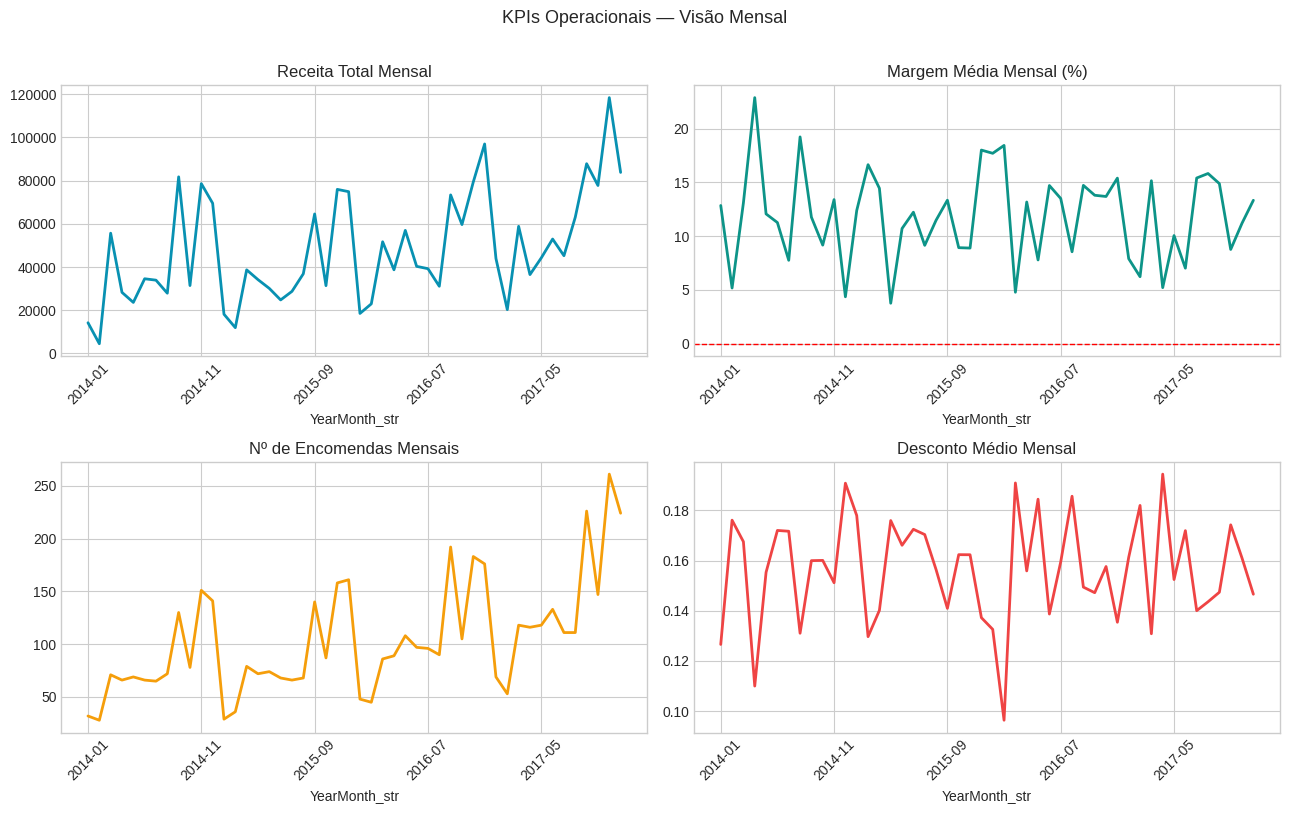

In [ ]:
# Calcular KPIs mensais
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y') # Convert 'Order Date' to datetime objects
df['YearMonth'] = df['Order Date'].dt.to_period('M')
df['Profit_Margin'] = df['Profit'] / df['Sales']

kpis_mensal = df.groupby('YearMonth').agg(
    Receita_Total      = ('Sales', 'sum'),
    Lucro_Total        = ('Profit', 'sum'),
    Margem_Media       = ('Profit_Margin', 'mean'),
    Num_Encomendas     = ('Order ID', 'nunique'),
    Valor_Medio_Enc    = ('Sales', 'mean'),
    Desconto_Medio     = ('Discount', 'mean')
).reset_index()

kpis_mensal['YearMonth_str'] = kpis_mensal['YearMonth'].astype(str)
kpis_mensal['Margem_Media_pct'] = kpis_mensal['Margem_Media'] * 100

print("\nKPIs Mensais (últimos 6 meses):")
print(kpis_mensal.tail(6)[['YearMonth_str', 'Receita_Total', 'Lucro_Total', 'Margem_Media_pct', 'Num_Encomendas']].to_string(index=False))

# Visualizar
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

kpis_mensal.plot(x='YearMonth_str', y='Receita_Total', ax=axes[0,0], color=BLUE, linewidth=2, legend=False)
axes[0,0].set_title('Receita Total Mensal')
axes[0,0].tick_params(axis='x', rotation=45)

kpis_mensal.plot(x='YearMonth_str', y='Margem_Media_pct', ax=axes[0,1], color=GREEN, linewidth=2, legend=False)
axes[0,1].set_title('Margem Média Mensal (%)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1)

kpis_mensal.plot(x='YearMonth_str', y='Num_Encomendas', ax=axes[1,0], color=ORANGE, linewidth=2, legend=False)
axes[1,0].set_title('Nº de Encomendas Mensais')
axes[1,0].tick_params(axis='x', rotation=45)

kpis_mensal.plot(x='YearMonth_str', y='Desconto_Medio', ax=axes[1,1], color=RED, linewidth=2, legend=False)
axes[1,1].set_title('Desconto Médio Mensal')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('KPIs Operacionais — Visão Mensal', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/content/kpis_mensais.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 5 — ANÁLISE DE RENTABILIDADE POR CATEGORIA E DESCONTO

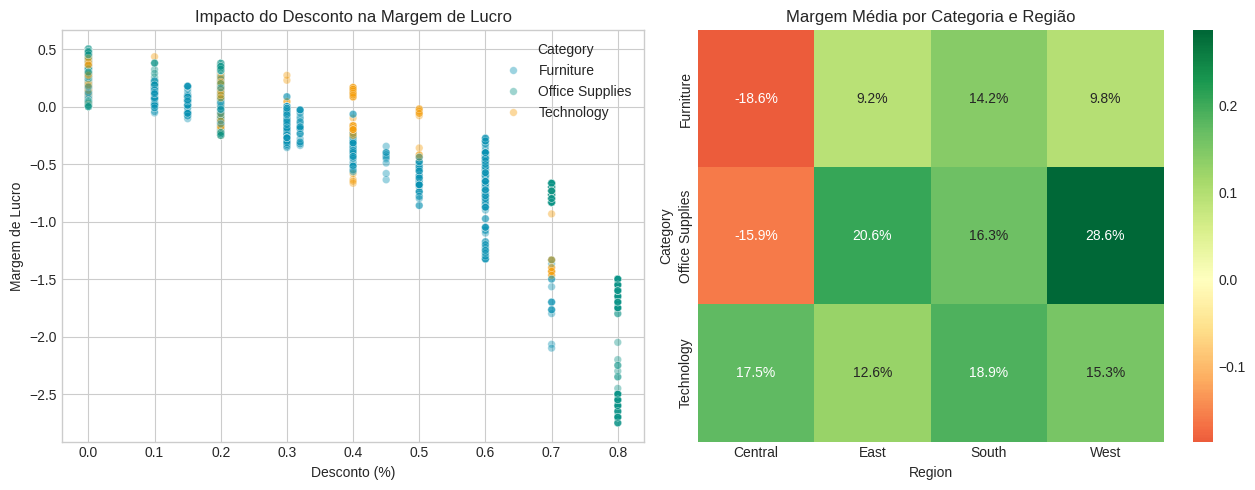

In [ ]:
# Impacto do desconto na margem
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x='Discount', y='Profit_Margin',
                hue='Category', palette=[BLUE, GREEN, ORANGE],
                alpha=0.4, s=30, ax=axes[0])
axes[0].set_title('Impacto do Desconto na Margem de Lucro')
axes[0].set_xlabel('Desconto (%)')
axes[0].set_ylabel('Margem de Lucro')

# Margem média por categoria e região
pivot = df.pivot_table(values='Profit_Margin', index='Category', columns='Region', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', ax=axes[1], center=0)
axes[1].set_title('Margem Média por Categoria e Região')

plt.tight_layout()
plt.savefig('/content/margem_analise.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 6 — EXPORTAR PARA POWER BI

In [ ]:
df.to_csv('/content/superstore_analise.csv', index=False)
vendas_produto.to_csv('/content/abc_produtos.csv', index=False)
kpis_mensal.to_csv('/content/kpis_mensais.csv', index=False)

print("\nFicheiros exportados para Power BI:")
print("  - superstore_analise.csv  (dados completos)")
print("  - abc_produtos.csv        (classificação ABC)")
print("  - kpis_mensais.csv        (KPIs agregados)")


Ficheiros exportados para Power BI:
  - superstore_analise.csv  (dados completos)
  - abc_produtos.csv        (classificação ABC)
  - kpis_mensais.csv        (KPIs agregados)


> PERGUNTAS DE REFLEXÃO

In [ ]:
# 1. Que produtos da Classe C têm margens elevadas?
#    Deveriam ser descontinuados ou mantidos por outra razão?
#
# 2. Existe correlação entre desconto e margem negativa?
#    Quantifica-a e sugere uma política de descontos.
#
# 3. EXTENSÃO: Aplica a análise ABC aos clientes (por receita gerada).
#    Os clientes Classe A coincidem com os segmentos mais rentáveis?
#
# 4. Que KPIs adicionais faria sentido monitorizar num dashboard executivo?
#    Define-os com a fórmula e o intervalo desejado (target).